In [1]:
import os
import matplotlib.pyplot as mp
import pandas as pd
import seaborn as sb

from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

In [2]:
dataset = pd.read_csv("iris.csv")
dataset

,sepal.length,sepal.width,petal.length,petal.width,variety
0,5.1,3.5,1.4,0.2,Setosa
1,4.9,3.0,1.4,0.2,Setosa
2,4.7,3.2,1.3,0.2,Setosa
3,4.6,3.1,1.5,0.2,Setosa
4,5.0,3.6,1.4,0.2,Setosa
...,...,...,...,...,...
145,6.7,3.0,5.2,2.3,Virginica
146,6.3,2.5,5.0,1.9,Virginica
147,6.5,3.0,5.2,2.0,Virginica
148,6.2,3.4,5.4,2.3,Virginica


In [3]:
fields = dataset.iloc[:, 0:4].values

print(fields)

[[5.1 3.5 1.4 0.2]
 [4.9 3.  1.4 0.2]
 [4.7 3.2 1.3 0.2]
 [4.6 3.1 1.5 0.2]
 [5.  3.6 1.4 0.2]
 [5.4 3.9 1.7 0.4]
 [4.6 3.4 1.4 0.3]
 [5.  3.4 1.5 0.2]
 [4.4 2.9 1.4 0.2]
 [4.9 3.1 1.5 0.1]
 [5.4 3.7 1.5 0.2]
 [4.8 3.4 1.6 0.2]
 [4.8 3.  1.4 0.1]
 [4.3 3.  1.1 0.1]
 [5.8 4.  1.2 0.2]
 [5.7 4.4 1.5 0.4]
 [5.4 3.9 1.3 0.4]
 [5.1 3.5 1.4 0.3]
 [5.7 3.8 1.7 0.3]
 [5.1 3.8 1.5 0.3]
 [5.4 3.4 1.7 0.2]
 [5.1 3.7 1.5 0.4]
 [4.6 3.6 1.  0.2]
 [5.1 3.3 1.7 0.5]
 [4.8 3.4 1.9 0.2]
 [5.  3.  1.6 0.2]
 [5.  3.4 1.6 0.4]
 [5.2 3.5 1.5 0.2]
 [5.2 3.4 1.4 0.2]
 [4.7 3.2 1.6 0.2]
 [4.8 3.1 1.6 0.2]
 [5.4 3.4 1.5 0.4]
 [5.2 4.1 1.5 0.1]
 [5.5 4.2 1.4 0.2]
 [4.9 3.1 1.5 0.2]
 [5.  3.2 1.2 0.2]
 [5.5 3.5 1.3 0.2]
 [4.9 3.6 1.4 0.1]
 [4.4 3.  1.3 0.2]
 [5.1 3.4 1.5 0.2]
 [5.  3.5 1.3 0.3]
 [4.5 2.3 1.3 0.3]
 [4.4 3.2 1.3 0.2]
 [5.  3.5 1.6 0.6]
 [5.1 3.8 1.9 0.4]
 [4.8 3.  1.4 0.3]
 [5.1 3.8 1.6 0.2]
 [4.6 3.2 1.4 0.2]
 [5.3 3.7 1.5 0.2]
 [5.  3.3 1.4 0.2]
 [7.  3.2 4.7 1.4]
 [6.4 3.2 4.5 1.5]
 [6.9 3.1 4.

In [4]:
import warnings
warnings.filterwarnings("ignore")

In [5]:
wcss = []

for index in range(1, 11):
    kmeans = KMeans(
        n_clusters=index,
        init="k-means++",
        random_state=2
    )
    
    kmeans.fit(fields)
    wcss.append(kmeans.inertia_)

wcss

[681.3706,
 152.3479517603579,
 78.85144142614601,
 57.228473214285714,
 49.84221386276558,
 41.840300724637686,
 37.74396635382162,
 30.900849644937104,
 28.383730222485372,
 26.54619667270182]

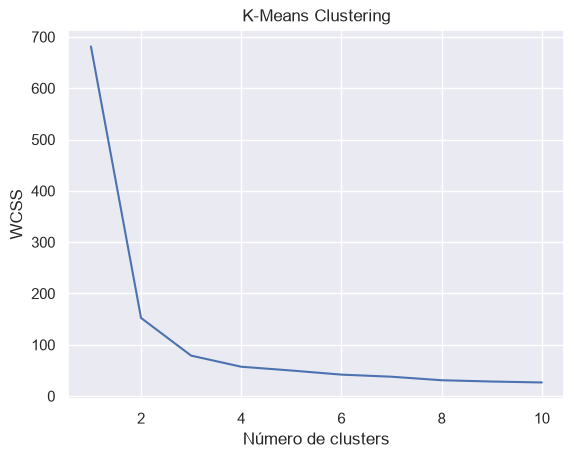

In [6]:
# Gráfico del codo
sb.set()

mp.plot(range(1, 11), wcss)
mp.title("K-Means Clustering")
mp.xlabel("Número de clusters")
mp.ylabel("WCSS")
mp.show()

In [7]:
for j in range(2, 11):
    kmeans = KMeans(
        n_clusters=j,
        random_state=42
    )
    
    kmeans.fit_predict(fields)
    
    score = silhouette_score(
        fields,
        kmeans.labels_,
        metric="euclidean"
    )
    
    print("Score Silhouette; k =", j, ":", score)

Score Silhouette; k = 2 : 0.6810461692117464
Score Silhouette; k = 3 : 0.5511916046195922
Score Silhouette; k = 4 : 0.4976433179321928
Score Silhouette; k = 5 : 0.4930804067193526
Score Silhouette; k = 6 : 0.36784649847122486
Score Silhouette; k = 7 : 0.3542978877198852
Score Silhouette; k = 8 : 0.34467972180562
Score Silhouette; k = 9 : 0.315588785338977
Score Silhouette; k = 10 : 0.30141437453251435


In [8]:
kmeans = KMeans(
    n_clusters=3,
    init="k-means++",
    random_state=42
)

cluster_values = kmeans.fit_predict(fields)

print(cluster_values)

[1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1
 1 1 1 1 1 1 1 1 1 1 1 1 1 0 2 0 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2
 2 2 2 0 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 0 2 0 0 0 0 2 0 0 0 0
 0 0 2 2 0 0 0 0 2 0 2 0 2 0 0 2 2 0 0 0 0 0 2 0 0 0 0 2 0 0 0 2 0 0 0 2 0
 0 2]


In [9]:
dataset_original = dataset.copy()
dataset_original["grupo_kmeans"] = cluster_values

dataset_original

,sepal.length,sepal.width,petal.length,petal.width,variety,grupo_kmeans
0,5.1,3.5,1.4,0.2,Setosa,1
1,4.9,3.0,1.4,0.2,Setosa,1
2,4.7,3.2,1.3,0.2,Setosa,1
3,4.6,3.1,1.5,0.2,Setosa,1
4,5.0,3.6,1.4,0.2,Setosa,1
...,...,...,...,...,...,...
145,6.7,3.0,5.2,2.3,Virginica,0
146,6.3,2.5,5.0,1.9,Virginica,2
147,6.5,3.0,5.2,2.0,Virginica,0
148,6.2,3.4,5.4,2.3,Virginica,0


In [10]:
# Datos para PCA
fields2 = dataset.iloc[:, 0:4].values

from sklearn import decomposition

pca = decomposition.PCA(n_components=2)
pca.fit(fields2)

fields2 = pca.transform(fields2)

fields2

array([[-2.68412563,  0.31939725],
       [-2.71414169, -0.17700123],
       [-2.88899057, -0.14494943],
       [-2.74534286, -0.31829898],
       [-2.72871654,  0.32675451],
       [-2.28085963,  0.74133045],
       [-2.82053775, -0.08946138],
       [-2.62614497,  0.16338496],
       [-2.88638273, -0.57831175],
       [-2.6727558 , -0.11377425],
       [-2.50694709,  0.6450689 ],
       [-2.61275523,  0.01472994],
       [-2.78610927, -0.235112  ],
       [-3.22380374, -0.51139459],
       [-2.64475039,  1.17876464],
       [-2.38603903,  1.33806233],
       [-2.62352788,  0.81067951],
       [-2.64829671,  0.31184914],
       [-2.19982032,  0.87283904],
       [-2.5879864 ,  0.51356031],
       [-2.31025622,  0.39134594],
       [-2.54370523,  0.43299606],
       [-3.21593942,  0.13346807],
       [-2.30273318,  0.09870885],
       [-2.35575405, -0.03728186],
       [-2.50666891, -0.14601688],
       [-2.46882007,  0.13095149],
       [-2.56231991,  0.36771886],
       [-2.63953472,

In [11]:
# Calcular WCSS después de PCA
wcss2 = []

for index in range(1, 11):
    kmeans = KMeans(
        n_clusters=index,
        init="k-means++",
        random_state=2
    )
    
    kmeans.fit(fields2)
    wcss2.append(kmeans.inertia_)

wcss2

[666.1659556405607,
 137.15530112818402,
 63.81994202200114,
 42.38609427321201,
 35.60096738779258,
 28.248464076196683,
 24.71593275869134,
 20.047235886335606,
 16.057834999187616,
 14.421718896211253]

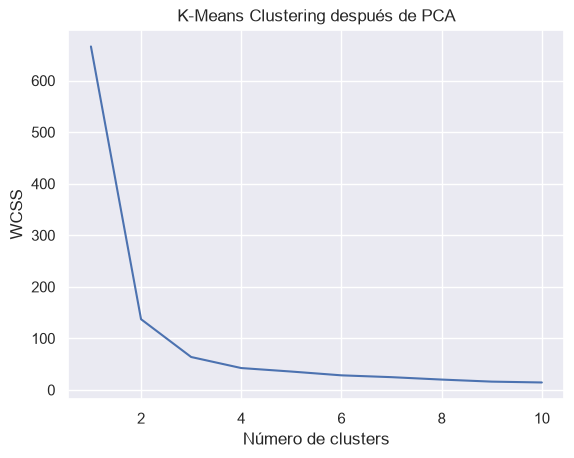

In [12]:
# Gráfico del codo después de PCA
sb.set()

mp.plot(range(1, 11), wcss2)
mp.title("K-Means Clustering después de PCA")
mp.xlabel("Número de clusters")
mp.ylabel("WCSS")
mp.show()

In [13]:
# Silhouette después de PCA
for j in range(2, 11):
    kmeans = KMeans(
        n_clusters=j,
        random_state=42
    )

    kmeans.fit_predict(fields2)

    score = silhouette_score(
        fields2,
        kmeans.labels_,
        metric="euclidean"
    )

    print("Score Silhouette; k =", j, ":", score)

Score Silhouette; k = 2 : 0.705670322510211
Score Silhouette; k = 3 : 0.5976764219547994
Score Silhouette; k = 4 : 0.5577409232246783
Score Silhouette; k = 5 : 0.5100407194899199
Score Silhouette; k = 6 : 0.40319738737442684
Score Silhouette; k = 7 : 0.38682639977136096
Score Silhouette; k = 8 : 0.44076033249654034
Score Silhouette; k = 9 : 0.40201438763663666
Score Silhouette; k = 10 : 0.4158865801753239


In [14]:
# K-Means después de PCA con 3 clusters
kmeans_pca = KMeans(
    n_clusters=3,
    init="k-means++",
    random_state=42
)

cluster_values_pca = kmeans_pca.fit_predict(fields2)

print(cluster_values_pca)

[1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1
 1 1 1 1 1 1 1 1 1 1 1 1 1 0 2 0 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2
 2 2 2 0 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 0 2 0 0 0 0 2 0 0 0 0
 0 0 2 2 0 0 0 0 2 0 2 0 2 0 0 2 2 0 0 0 0 0 2 0 0 0 0 2 0 0 0 2 0 0 0 2 0
 0 2]


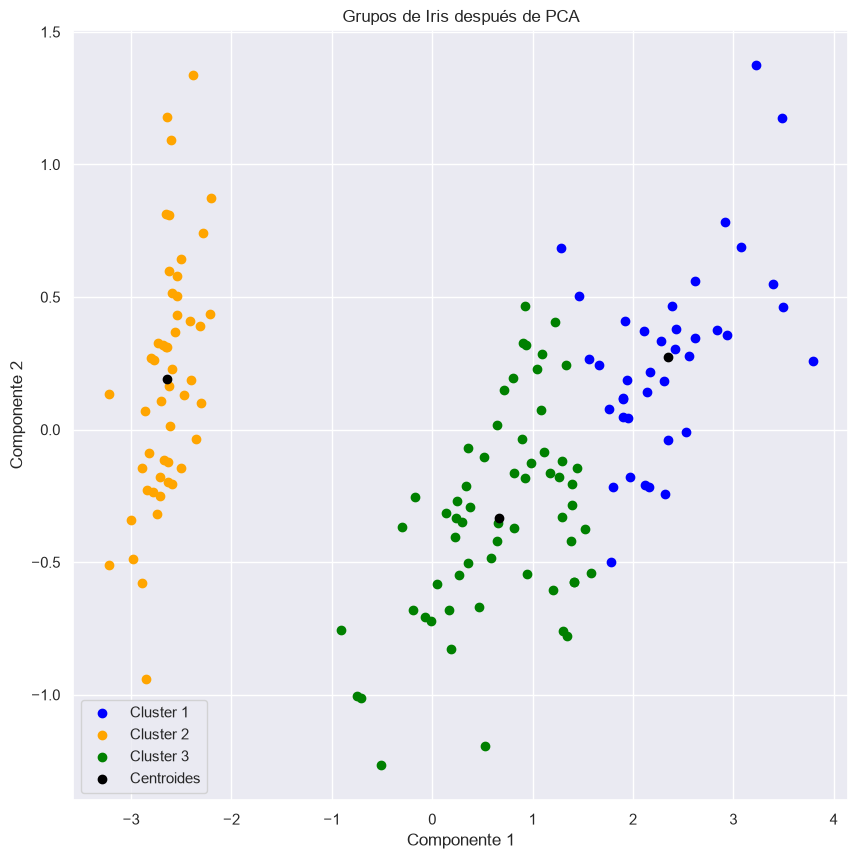

In [15]:
# Gráfica de los clusters después de PCA
mp.figure(figsize=(10, 10))

mp.scatter(
    fields2[cluster_values_pca == 0, 0],
    fields2[cluster_values_pca == 0, 1],
    c="blue",
    label="Cluster 1"
)

mp.scatter(
    fields2[cluster_values_pca == 1, 0],
    fields2[cluster_values_pca == 1, 1],
    c="orange",
    label="Cluster 2"
)

mp.scatter(
    fields2[cluster_values_pca == 2, 0],
    fields2[cluster_values_pca == 2, 1],
    c="green",
    label="Cluster 3"
)

# Centroides
mp.scatter(
    kmeans_pca.cluster_centers_[:, 0],
    kmeans_pca.cluster_centers_[:, 1],
    c="black",
    label="Centroides"
)

mp.title("Grupos de Iris después de PCA")
mp.xlabel("Componente 1")
mp.ylabel("Componente 2")
mp.legend()

mp.show()

In [16]:
# Comparar grupos antes y después de PCA
comparacion = pd.DataFrame({
    "Grupo_original": cluster_values,
    "Grupo_PCA": cluster_values_pca
})

comparacion

,Grupo_original,Grupo_PCA
0,1,1
1,1,1
2,1,1
3,1,1
4,1,1
...,...,...
145,0,0
146,2,2
147,0,0
148,0,0


In [17]:
# Tabla de comparación
pd.crosstab(
    comparacion["Grupo_original"],
    comparacion["Grupo_PCA"]
)

Grupo_PCA,0,1,2
Grupo_original,,,
0,39,0,0
1,0,50,0
2,0,0,61
